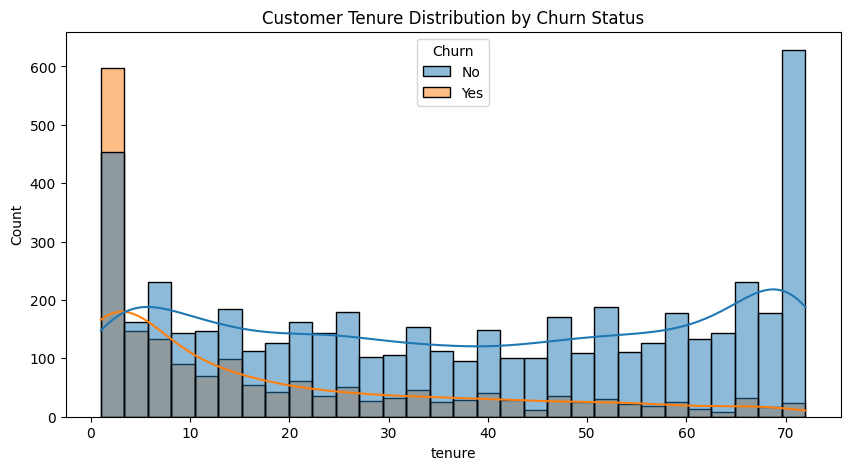

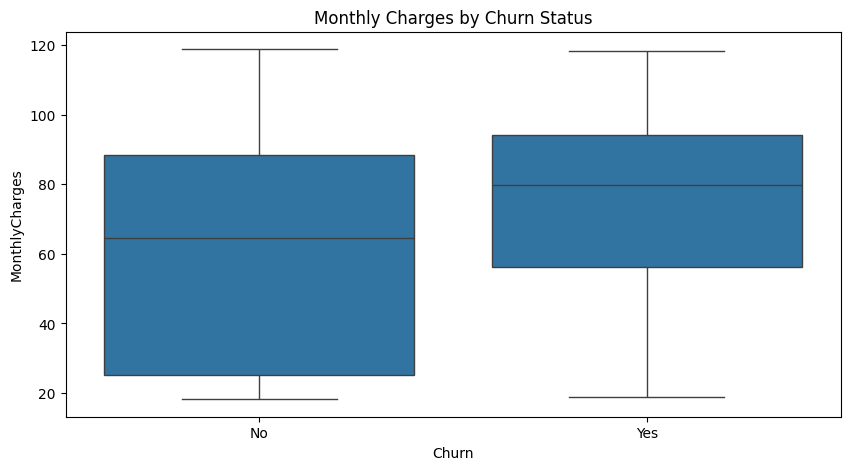

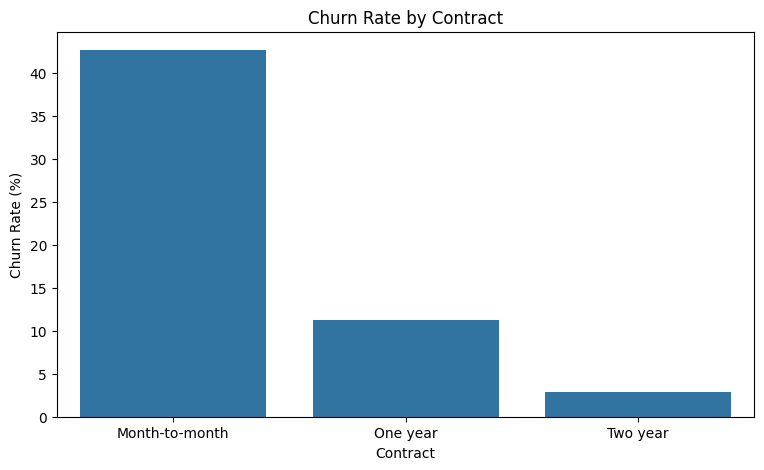

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.show()

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.show()



contract_rates = churn_summary(data, "Contract")

plt.figure(figsize=(9, 5))

sns.barplot(
    x=contract_rates.index,
    y=contract_rates["churn_rate"]
)

plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract")

plt.show()

In [15]:
mean1 = churned_tenure.mean()
mean2 = retained_tenure.mean()

std1 = churned_tenure.std()
std2 = retained_tenure.std()

n1 = len(churned_tenure)
n2 = len(retained_tenure)

pooled_std = np.sqrt(
    (
        (n1 - 1) * std1**2
        + (n2 - 1) * std2**2
    )
    / (n1 + n2 - 2)
)

cohens_d = (mean1 - mean2) / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: -0.8568568598647608


In [14]:
churned_tenure = data.loc[
    data["Churn_Target"] == 1,
    "tenure"
]

retained_tenure = data.loc[
    data["Churn_Target"] == 0,
    "tenure"
]

t_stat, p_value = stats.ttest_ind(
    churned_tenure,
    retained_tenure,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)


if p_value < 0.05:
    print("Tenure differs significantly between churned and retained customers.")
else:
    print("No statistically significant difference.")

t-statistic: -34.97187009750348
p-value: 2.3470747188949526e-234
Tenure differs significantly between churned and retained customers.


In [12]:
table = pd.crosstab(
    data["Contract"],
    data["Churn"]
)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

n = table.sum().sum()

cramers_v = np.sqrt(
    chi2 / (
        n * (min(table.shape) - 1)
    )
)

print("Cramer's V:", cramers_v)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Significant association between Contract and Churn.")
else:
    print("No statistically significant association.")

Cramer's V: 0.4095604189089921
Chi-square: 1179.5458287339445
p-value: 7.326182186265472e-257
Degrees of freedom: 2
Significant association between Contract and Churn.


In [10]:
def churn_summary(df, column):
    result = (
        df.groupby(column)["Churn_Target"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "customers",
            "sum": "churned",
            "mean": "churn_rate"
        })
    )
    
    result["churn_rate"] *= 100
    
    return result.sort_values(
        "churn_rate",
        ascending=False
    )

churn_summary(data, "Contract")
churn_summary(data, "PaymentMethod")
churn_summary(data, "InternetService")
churn_summary(data, "TechSupport")
churn_summary(data, "OnlineSecurity")

,customers,churned,churn_rate
OnlineSecurity,,,
No,3497,1461,41.778667
Yes,2015,295,14.640199
No internet service,1520,113,7.434211


In [3]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

data = pd.read_csv("../data/processed/telco_customer_clean.csv")

print(data.shape)

data.describe().T

data.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].agg(["mean", "median"])

(7032, 23)


tenure        MonthlyCharges        TotalCharges         
            mean median           mean median         mean   median
Churn                                                              
No     37.650010   38.0      61.307408  64.45  2555.344141  1683.60
Yes    17.979133   10.0      74.441332  79.65  1531.796094   703.55